In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

### xBD

In [2]:
data_dir = '/home/gridsan/groups/MV4SAR/XBD/tier3/'
images_dir = f'{data_dir}/images'
labels_dir = f'{data_dir}/labels'

In [3]:
# Get full file paths
image_files = sorted([os.path.join(images_dir, f) for f in os.listdir(images_dir) if os.path.isfile(os.path.join(images_dir, f))])
label_files = sorted([os.path.join(labels_dir, f) for f in os.listdir(labels_dir) if os.path.isfile(os.path.join(labels_dir, f))])

# Display first few files
print("Image Files:", image_files[:5])  # Show first 5 image files
print("Label Files:", label_files[:5])  # Show first 5 label files

Image Files: ['/home/gridsan/groups/MV4SAR/XBD/tier3//images/joplin-tornado_00000000_post_disaster.png', '/home/gridsan/groups/MV4SAR/XBD/tier3//images/joplin-tornado_00000000_pre_disaster.png', '/home/gridsan/groups/MV4SAR/XBD/tier3//images/joplin-tornado_00000001_post_disaster.png', '/home/gridsan/groups/MV4SAR/XBD/tier3//images/joplin-tornado_00000001_pre_disaster.png', '/home/gridsan/groups/MV4SAR/XBD/tier3//images/joplin-tornado_00000002_post_disaster.png']
Label Files: ['/home/gridsan/groups/MV4SAR/XBD/tier3//labels/joplin-tornado_00000000_post_disaster.json', '/home/gridsan/groups/MV4SAR/XBD/tier3//labels/joplin-tornado_00000000_pre_disaster.json', '/home/gridsan/groups/MV4SAR/XBD/tier3//labels/joplin-tornado_00000001_post_disaster.json', '/home/gridsan/groups/MV4SAR/XBD/tier3//labels/joplin-tornado_00000001_pre_disaster.json', '/home/gridsan/groups/MV4SAR/XBD/tier3//labels/joplin-tornado_00000002_post_disaster.json']


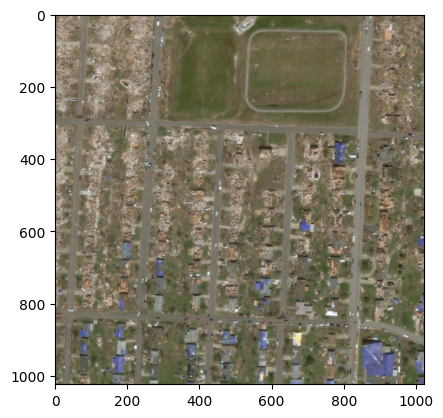

In [5]:
im = Image.open(image_files[0])
plt.imshow(im)

### xView

In [2]:
import json
import geopandas as gpd
from shapely.geometry import Polygon
import os
from PIL import Image
import numpy as np
from tqdm import tqdm

In [3]:
geojson_file = '/home/gridsan/manderson/ovdsat/data/xview/xView_train.geojson'
image_folder = '/home/gridsan/manderson/ovdsat/data/xview/train_images'
output_coco_file = "/home/gridsan/manderson/ovdsat/data/xview/xView_coco.json"

In [4]:
# Load GeoJSON
gdf = gpd.read_file(geojson_file)

In [5]:
gdf.head()

,bounds_imcoords,edited_by,cat_id,type_id,ingest_time,index_right,image_id,point_geom,feature_id,grid_file,geometry
0,"2712,1145,2746,1177",wwoscarbecerril,1040010028371A00,73,2017-07-24 12:49:09.118000+00:00,2356,2355.tif,0101000020E6100000616E4E6406A256C03BE6ADA0D621...,374410,Grid2.shp,"POLYGON ((-90.5317 14.56604, -90.5317 14.56614..."
1,"2720,2233,2760,2288",wwoscarbecerril,1040010028371A00,73,2017-07-24 17:26:05.701000+00:00,2356,2355.tif,0101000020E6100000042D0CC705A256C0004F7071E71F...,394393,Grid2.shp,"POLYGON ((-90.53167 14.56222, -90.53167 14.562..."
2,"2687,1338,2740,1399",wwoscarbecerril,1040010028371A00,73,2017-07-24 12:45:09.081000+00:00,2356,2355.tif,0101000020E6100000B29F7E4707A256C0000AE6537921...,374031,Grid2.shp,"POLYGON ((-90.53179 14.56527, -90.53179 14.565..."
3,"2691,1201,2730,1268",wwoscarbecerril,1040010028371A00,73,2017-07-24 12:49:09.118000+00:00,2356,2355.tif,0101000020E6100000CE53137207A256C00EBF7084B521...,374409,Grid2.shp,"POLYGON ((-90.53177 14.56572, -90.53177 14.565..."
4,"2671,838,2714,869",wwoscarbecerril,1040010028371A00,73,2017-07-24 13:20:38.280000+00:00,2356,2355.tif,0101000020E610000060DE147608A256C05D6A384C6122...,377368,Grid2.shp,"POLYGON ((-90.53184 14.5671, -90.53184 14.5672..."


In [6]:
category_mapping = gdf["type_id"].unique()

In [7]:
category_mapping

array([73, 18, 83, 21, 77, 19, 20, 25, 24, 26, 27, 60, 12, 64, 28, 89, 86,
       23, 72, 71, 32, 13, 11, 84, 15, 74, 65, 29, 79, 63, 51, 47, 41, 50,
       42, 44, 40, 59, 55, 91, 54, 49, 17, 57, 56, 93, 75, 76, 35, 36, 37,
       34, 82, 61, 66, 53, 38, 94, 45, 52, 62, 33], dtype=int32)

In [5]:
# Initialize COCO structure
coco_data = {
    "images": [],
    "annotations": [],
    "categories": []
}

# Map categories (create unique IDs)
category_mapping = {cat: idx + 1 for idx, cat in enumerate(gdf["cat_id"].unique())}

# Populate COCO categories
for category, category_id in category_mapping.items():
    coco_data["categories"].append({"id": category_id, "name": str(category), "supercategory": "none"})

# Image tracking
image_id_set = set()
annotation_id = 0

# Iterate through GeoJSON data
for idx, row in tqdm(gdf.iterrows(), total=len(gdf), desc="Processing Features"):
    image_id = row["image_id"]  # Extract image_id (already includes .tif extension)
    image_path = os.path.join(image_folder, image_id)  # Use image_id directly

    if not os.path.exists(image_path):
        print(f"Warning: Image {image_id} not found. Skipping.")
        continue

    # Get image size
    with Image.open(image_path) as img:
        width, height = img.size

    # Add image entry (only once per image_id)
    if image_id not in image_id_set:
        coco_data["images"].append({
            "id": image_id,
            "file_name": image_id,  # Keep original .tif extension
            "width": width,
            "height": height
        })
        image_id_set.add(image_id)

    # Parse bounding box (assuming bounds_imcoords = [x_min, y_min, x_max, y_max])
    if isinstance(row["bounds_imcoords"], str):
        bbox_coords = list(map(float, row["bounds_imcoords"].split(",")))
        x_min, y_min, x_max, y_max = bbox_coords
        bbox = [x_min, y_min, x_max - x_min, y_max - y_min]  # COCO format: [x, y, width, height]
    else:
        print(f"Skipping invalid bbox for image {image_id}")
        continue

    # Parse segmentation (if geometry is a Polygon)
    segmentation = []
    if isinstance(row.geometry, Polygon):
        segmentation = [list(np.ravel(row.geometry.exterior.coords.xy))]

    # Add annotation
    coco_data["annotations"].append({
        "id": annotation_id,
        "image_id": image_id,
        "category_id": category_mapping[row["cat_id"]],
        "bbox": bbox,
        "segmentation": segmentation if segmentation else None,
        "area": row.geometry.area if row.geometry else bbox[2] * bbox[3],  # Use bbox area if geometry is missing
        "iscrowd": 0
    })
    annotation_id += 1

# Save COCO JSON
with open(output_coco_file, "w") as f:
    json.dump(coco_data, f, indent=4)

print(f"COCO format saved as {output_coco_file}")

Processing Features:  10%|█         | 61937/601937 [10:55<2:39:14, 56.52it/s] Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f932f154e20>>
Traceback (most recent call last):
  File "/home/gridsan/manderson/.conda/envs/ovdsat/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
Processing Features:  10%|█         | 61948/601937 [10:55<1:35:14, 94.50it/s]


KeyboardInterrupt: 